In [9]:
import os
import numpy as np
import pandas as pd
import torch
from pyquaternion import Quaternion

metadata_csv = "nusc_val_metadata.csv"
camera_feat_dir = "/home/draiman/Desktop/Datasets_nuscenes/validation/fpn/CAM_FRONT"
target_sample_token = "fd8420396768425eabec9bdddf7e64b6"
camera_name = "CAM_FRONT"
fpn_level = 0
# stride_p2 = 8  # usually 4 or 8; must match features
metadata_df = pd.read_csv(metadata_csv)
print(f"Loaded {len(metadata_df)} metadata records.")

row = metadata_df.query(f"sample_token == '{target_sample_token}' and camera_name == '{camera_name}'")
if row.empty:
    raise RuntimeError("No matching camera record.")
row = row.iloc[0]
K = np.array(row["cam_intrinsic"].split(';'), dtype=np.float64).reshape(3, 3)
R = Quaternion([float(x) for x in row["sensor2ego_rotation"].split(';')]).rotation_matrix
T = np.array(row["sensor2ego_translation"].split(';'), dtype=np.float64)


feat_path = os.path.join(camera_feat_dir, f"{target_sample_token}_lvl{fpn_level}.pt")
cam_blob = torch.load(feat_path, map_location='cpu')
cam_feat = cam_blob['feat']
if cam_feat.ndim == 3:
    cam_feat = cam_feat.unsqueeze(0)
B, C, Hf, Wf = cam_feat.shape
print("Camera feature shape:", cam_feat.shape)


# ################################ New: Fixing Stide ###########################################
print(cam_blob.keys())
print(cam_blob['img_shape'][0])

# Get true input image shape
# Use the correct key; here, guess 'img_shape' but adjust if needed
if 'img_shape' in cam_blob:
    H_img, W_img, _ = cam_blob['img_shape'][0]  # (height, width)
else:
    # fallback: try to get from your metadata .csv file
    H_img = int(row['img_height'])  # add these fields to metadata if needed
    W_img = int(row['img_width'])
    # or set explicitly for nuScenes CAM_FRONT
    # H_img, W_img = 928, 1600

Hf, Wf = cam_feat.shape[-2], cam_feat.shape[-1]

stride_u = W_img / Wf
stride_v = H_img / Hf

assert abs(stride_u - stride_v) < 1e-2, f"Stride is asymmetric ({stride_u} vs {stride_v}); check preprocessing pipeline."

stride = stride_u  # Safe if assert passes
###########################################


# 2D grid spec 
cell_x, cell_y = 0.4, 0.25
x_min, x_max, y_min, y_max = 0.0, 50.0, -25.0, 25.0
H_bev = int(np.ceil((x_max - x_min) / cell_x))
W_bev = int(np.ceil((y_max - y_min) / cell_y))
print(f"BEV grid: {H_bev} x {W_bev}")


i = torch.arange(Hf, dtype=torch.float32) + 0.5
j = torch.arange(Wf, dtype=torch.float32) + 0.5
# V, U = torch.meshgrid(i * stride_p2, j * stride_p2, indexing='ij')  # old stride
V, U = torch.meshgrid(i * stride, j * stride, indexing='ij') # new stride
uv1 = np.stack([U.reshape(-1).numpy(), V.reshape(-1).numpy(), np.ones(Hf * Wf)], axis=0)
K_inv = np.linalg.inv(K)
rays_cam = K_inv @ uv1
rays_cam[1, :] *= -1.0
rays_ego = R @ rays_cam
dir_z = rays_ego[2, :]
cam_z = T[2]
s_ground = -cam_z / (dir_z + 1e-12)
Xg = T[0] + s_ground * rays_ego[0, :]
Yg = T[1] + s_ground * rays_ego[1, :]
ix = ((Xg - x_min) / cell_x).astype(np.int64)
iy = ((Yg - y_min) / cell_y).astype(np.int64)
valid = (ix >= 0) & (ix < H_bev) & (iy >= 0) & (iy < W_bev) & (s_ground > 0)


# 2D 
bev_grid = torch.zeros((B, C, H_bev, W_bev), dtype=cam_feat.dtype)
cam_feat_flat = cam_feat.reshape(B, C, -1)


# N = Hf * Wf
# for b in range(B):
#     for n in range(N):
#         if valid[n]:
#             bev_grid[b, :, ix[n], iy[n]] += cam_feat_flat[b, :, n]
# print(f"[2D] Valid splats: {valid.sum()} / {N}")



# Prepare valid indices
valid_idx = np.flatnonzero(valid)  # [num_valid]
ix_valid = torch.from_numpy(ix[valid]).long()      # [num_valid]
iy_valid = torch.from_numpy(iy[valid]).long()      # [num_valid]
cam_feat_valid = cam_feat_flat[:, :, valid_idx]    # [B, C, num_valid]

# Flatten spatial dimensions for scatter
for b in range(B):
    bev_flat = bev_grid[b].reshape(C, -1)  # [C, H_bev*W_bev]
    linear_idx = ix_valid * W_bev + iy_valid  # [num_valid]
    # Scatter-add: (accumulate all valid features into BEV at once)
    bev_flat.scatter_add_(
        1,  # dim
        linear_idx.unsqueeze(0).expand(C, -1),  # [C, num_valid]
        cam_feat_valid[b]  # [C, num_valid]
    )
    bev_grid[b] = bev_flat.reshape(C, H_bev, W_bev)

print(f"[2D] Valid splats: {valid.sum()} / {Hf*Wf}")


print("BEV grid shape:", bev_grid.shape)

Loaded 11892 metadata records.
Camera feature shape: torch.Size([1, 256, 116, 200])
dict_keys(['feat', 'lidar2img', 'img_shape', 'level', 'cam_name', 'sample_idx'])
(928, 1600, 3)
BEV grid: 125 x 200
[2D] Valid splats: 11394 / 23200
BEV grid shape: torch.Size([1, 256, 125, 200])


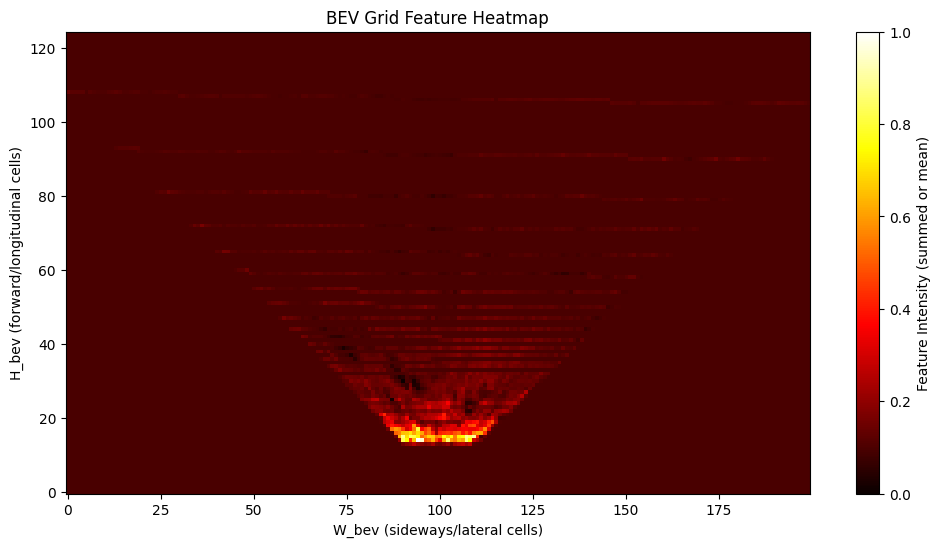

In [8]:
import matplotlib.pyplot as plt
import torch

# Suppose your BEV grid is named bev_grid, shape: [B, C, H_bev, W_bev]
# If you followed your previous code, it's likely [1, 256, 125, 200]

# Remove batch dimension (if present)
bev_img = bev_grid[0]  # shape: [C, H_bev, W_bev]

# Collapse feature channels: sum or mean
# bev_heat = bev_img.sum(dim=0)   # shape: [H_bev, W_bev]
# OR for mean:
bev_heat = bev_img.mean(dim=0)

# Optional: Normalize for display (0 to 1)
bev_heat = bev_heat.cpu().numpy()
bev_heat = (bev_heat - bev_heat.min()) / (bev_heat.max() - bev_heat.min() + 1e-8)

plt.figure(figsize=(12, 6))
plt.imshow(bev_heat, cmap='hot', aspect='auto', origin='lower')
plt.colorbar(label="Feature Intensity (summed or mean)")
plt.title("BEV Grid Feature Heatmap")
plt.xlabel("W_bev (sideways/lateral cells)")
plt.ylabel("H_bev (forward/longitudinal cells)")
plt.show()

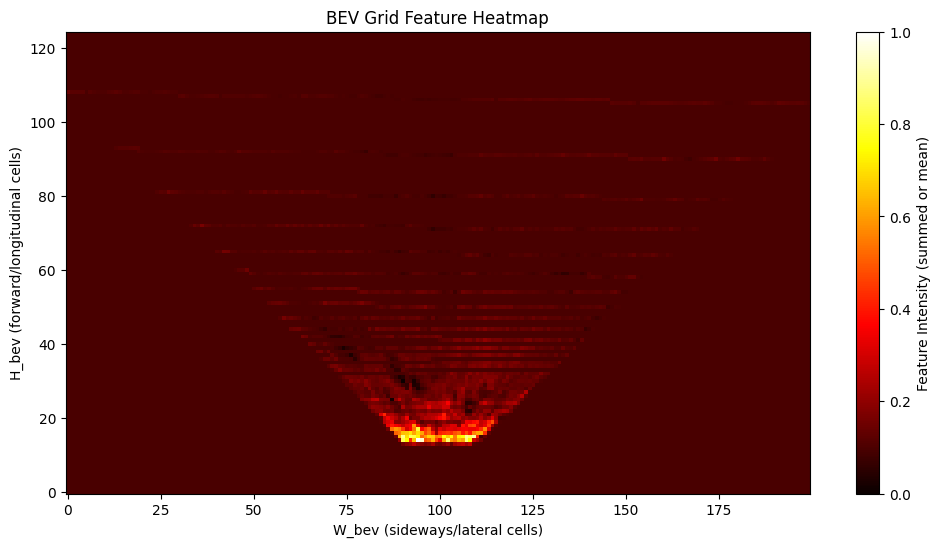

In [6]:
import matplotlib.pyplot as plt
import torch

# Suppose your BEV grid is named bev_grid, shape: [B, C, H_bev, W_bev]
# If you followed your previous code, it's likely [1, 256, 125, 200]

# Remove batch dimension (if present)
bev_img = bev_grid[0]  # shape: [C, H_bev, W_bev]

# Collapse feature channels: sum or mean
# bev_heat = bev_img.sum(dim=0)   # shape: [H_bev, W_bev]
# OR for mean:
bev_heat = bev_img.mean(dim=0)

# Optional: Normalize for display (0 to 1)
bev_heat = bev_heat.cpu().numpy()
bev_heat = (bev_heat - bev_heat.min()) / (bev_heat.max() - bev_heat.min() + 1e-8)

plt.figure(figsize=(12, 6))
plt.imshow(bev_heat, cmap='hot', aspect='auto', origin='lower')
plt.colorbar(label="Feature Intensity (summed or mean)")
plt.title("BEV Grid Feature Heatmap")
plt.xlabel("W_bev (sideways/lateral cells)")
plt.ylabel("H_bev (forward/longitudinal cells)")
plt.show()